# Mission 1: 굴뚝 위치 탐지 (Object Detection)

## 문제 개요
- Kompsat-3/3A 위성 이미지에서 굴뚝 위치를 바운딩 박스로 탐지
- YOLOv8 모델 사용
- mAP@IoU=0.5 지표로 평가
- Training: 8,052개, Validation: 1,006개

In [15]:
import os
import json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
from ultralytics import YOLO
import torch
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# 랜덤 시드 고정
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0+cpu
CUDA available: False


## 1. 데이터 경로 설정 및 확인

In [18]:
# 데이터 경로 설정
BASE_PATH = r"C:\Users\USER\Documents\python\DCC\53.대기오염 배출원 공간 분포 데이터\3.개방데이터\1.데이터"

# 이미지 경로
TRAIN_IMG_PATH = r"C:\Users\USER\Documents\python\DCC\53.대기오염 배출원 공간 분포 데이터\3.개방데이터\1.데이터\Training\01.원천데이터\TS_KS"
VAL_IMG_PATH = r"C:\Users\USER\Documents\python\DCC\53.대기오염 배출원 공간 분포 데이터\3.개방데이터\1.데이터\Validation\01.원천데이터\VS_KS"

# 라벨 경로
TRAIN_LABEL_PATH = f"{BASE_PATH}/Training/02.라벨링데이터/TL_KS_BBOX"
VAL_LABEL_PATH = f"{BASE_PATH}/Validation/02.라벨링데이터/VL_KS_BBOX"  # 검증 라벨 경로

# YOLO 데이터셋 구조 생성을 위한 경로
YOLO_DATASET_PATH = "yolo_dataset"

print(f"Training images: {TRAIN_IMG_PATH}")
print(f"Training labels: {TRAIN_LABEL_PATH}")
print(f"Validation labels: {VAL_LABEL_PATH}")

# 경로 존재 확인
print(f"\nPath checks:")
print(f"Train images exist: {os.path.exists(TRAIN_IMG_PATH)}")
print(f"Train labels exist: {os.path.exists(TRAIN_LABEL_PATH)}")
print(f"Val labels exist: {os.path.exists(VAL_LABEL_PATH)}")

Training images: C:\Users\USER\Documents\python\DCC\53.대기오염 배출원 공간 분포 데이터\3.개방데이터\1.데이터\Training\01.원천데이터\TS_KS
Training labels: C:\Users\USER\Documents\python\DCC\53.대기오염 배출원 공간 분포 데이터\3.개방데이터\1.데이터/Training/02.라벨링데이터/TL_KS_BBOX
Validation labels: C:\Users\USER\Documents\python\DCC\53.대기오염 배출원 공간 분포 데이터\3.개방데이터\1.데이터/Validation/02.라벨링데이터/VL_KS_BBOX

Path checks:
Train images exist: True
Train labels exist: True
Val labels exist: True


## 2. 데이터 분석 및 탐색

In [19]:
# 이미지 파일 수 확인
train_images = [f for f in os.listdir(TRAIN_IMG_PATH) if f.endswith('.jpg')]
print(f"Total training images: {len(train_images)}")

# 라벨 파일 수 확인
train_labels = [f for f in os.listdir(TRAIN_LABEL_PATH) if f.endswith('.json')]
print(f"Total training labels: {len(train_labels)}")

# 샘플 라벨 파일 분석
sample_label_file = os.path.join(TRAIN_LABEL_PATH, train_labels[0])
with open(sample_label_file, 'r', encoding='utf-8') as f:
    sample_data = json.load(f)

print(f"\nSample label structure:")
print(json.dumps(sample_data, indent=2, ensure_ascii=False)[:500] + "...")

Total training images: 8052
Total training labels: 8052

Sample label structure:
{
  "K3A_CHN_20161112052404_0.jpg63669": {
    "filename": "K3A_CHN_20161112052404_0.jpg",
    "size": 63669,
    "regions": [
      {
        "shape_attributes": {
          "name": "rect",
          "x": 107,
          "y": 364,
          "width": 86,
          "height": 18
        },
        "region_attributes": {
          "chi_id": "1"
        }
      },
      {
        "shape_attributes": {
          "name": "rect",
          "x": 219,
          "y": 387,
          "width": 76,
          "...


In [20]:
# 라벨 데이터 분석 함수
def analyze_labels(label_path):
    label_files = [f for f in os.listdir(label_path) if f.endswith('.json')]
    total_objects = 0
    images_with_objects = 0
    bbox_stats = []
    
    for label_file in label_files:
        with open(os.path.join(label_path, label_file), 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # JSON 구조에서 regions 추출
        for key in data:
            if 'regions' in data[key]:
                regions = data[key]['regions']
                if regions:
                    images_with_objects += 1
                    total_objects += len(regions)
                    
                    # 바운딩 박스 크기 통계
                    for region in regions:
                        if 'shape_attributes' in region:
                            shape = region['shape_attributes']
                            if shape.get('name') == 'rect':
                                bbox_stats.append({
                                    'width': shape.get('width', 0),
                                    'height': shape.get('height', 0),
                                    'x': shape.get('x', 0),
                                    'y': shape.get('y', 0)
                                })
    
    return {
        'total_images': len(label_files),
        'images_with_objects': images_with_objects,
        'total_objects': total_objects,
        'avg_objects_per_image': total_objects / len(label_files) if label_files else 0,
        'bbox_stats': bbox_stats
    }

# 학습 데이터 분석
train_analysis = analyze_labels(TRAIN_LABEL_PATH)
print("Training Data Analysis:")
print(f"Total images: {train_analysis['total_images']}")
print(f"Images with objects: {train_analysis['images_with_objects']}")
print(f"Total objects: {train_analysis['total_objects']}")
print(f"Average objects per image: {train_analysis['avg_objects_per_image']:.2f}")

# 바운딩 박스 통계
if train_analysis['bbox_stats']:
    bbox_df = pd.DataFrame(train_analysis['bbox_stats'])
    print(f"\nBounding Box Statistics:")
    print(bbox_df.describe())

Training Data Analysis:
Total images: 8052
Images with objects: 8052
Total objects: 10619
Average objects per image: 1.32

Bounding Box Statistics:
              width        height             x             y
count  10619.000000  10619.000000  10619.000000  10619.000000
mean      68.163481     44.587155    228.327997    237.497410
std       37.214854     35.094561    134.735008    138.039661
min        6.000000      5.000000      0.000000      0.000000
25%       42.000000     20.000000    102.000000    112.000000
50%       61.000000     32.000000    229.000000    227.000000
75%       85.000000     59.000000    350.000000    365.000000
max      334.000000    270.000000    491.000000    500.000000


## 3. 샘플 이미지 및 라벨 시각화

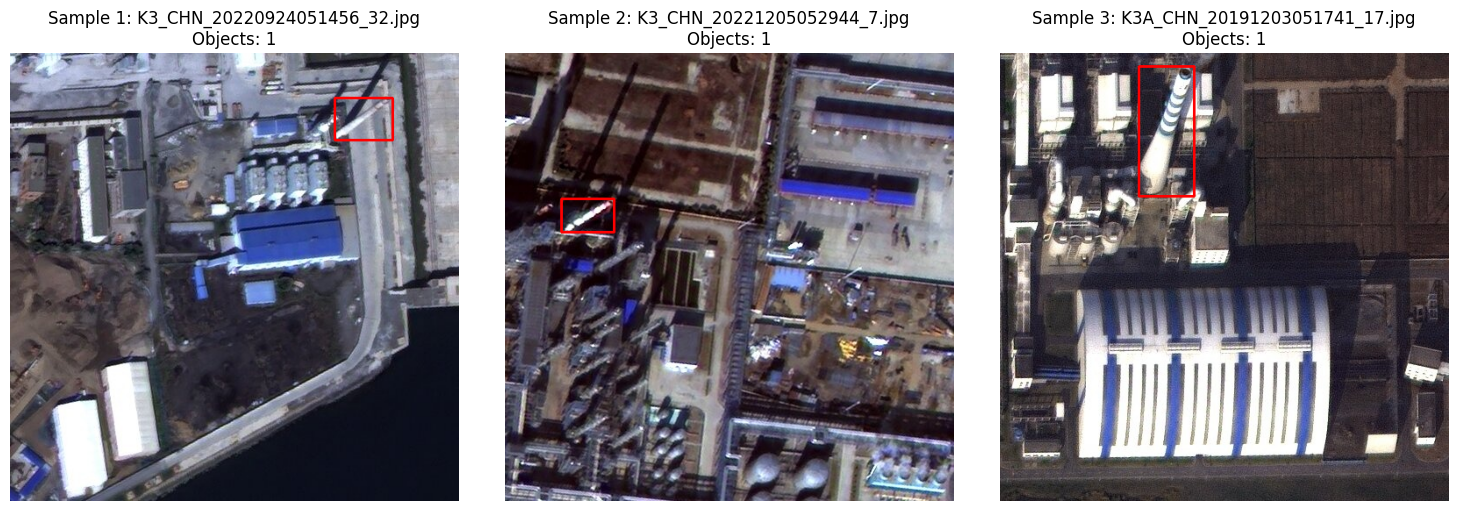

In [21]:
def visualize_sample(image_path, label_path, num_samples=3):
    """샘플 이미지와 바운딩 박스 시각화"""
    label_files = [f for f in os.listdir(label_path) if f.endswith('.json')]
    
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    if num_samples == 1:
        axes = [axes]
    
    for i in range(num_samples):
        # 랜덤 샘플 선택
        label_file = np.random.choice(label_files)
        
        # 라벨 데이터 로드
        with open(os.path.join(label_path, label_file), 'r', encoding='utf-8') as f:
            label_data = json.load(f)
        
        # 해당 이미지 파일명 추출
        img_filename = None
        regions = []
        
        for key in label_data:
            if 'filename' in label_data[key]:
                img_filename = label_data[key]['filename']
                regions = label_data[key].get('regions', [])
                break
        
        if not img_filename:
            continue
            
        # 이미지 로드
        img_path = os.path.join(image_path, img_filename)
        if not os.path.exists(img_path):
            continue
            
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # 바운딩 박스 그리기
        for region in regions:
            if 'shape_attributes' in region:
                shape = region['shape_attributes']
                if shape.get('name') == 'rect':
                    x, y = shape.get('x', 0), shape.get('y', 0)
                    w, h = shape.get('width', 0), shape.get('height', 0)
                    
                    # 바운딩 박스 그리기
                    cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)
        
        axes[i].imshow(image)
        axes[i].set_title(f'Sample {i+1}: {img_filename}\nObjects: {len(regions)}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# 샘플 시각화
visualize_sample(TRAIN_IMG_PATH, TRAIN_LABEL_PATH, 3)

## 4. YOLO 형식으로 데이터 변환

In [22]:
def create_yolo_dataset_structure():
    """YOLO 데이터셋 폴더 구조 생성"""
    os.makedirs(f"{YOLO_DATASET_PATH}/images/train", exist_ok=True)
    os.makedirs(f"{YOLO_DATASET_PATH}/images/val", exist_ok=True)
    os.makedirs(f"{YOLO_DATASET_PATH}/labels/train", exist_ok=True)
    os.makedirs(f"{YOLO_DATASET_PATH}/labels/val", exist_ok=True)

def convert_bbox_to_yolo(x, y, width, height, img_width, img_height):
    """바운딩 박스를 YOLO 형식으로 변환"""
    # 중심점 계산
    center_x = (x + width / 2) / img_width
    center_y = (y + height / 2) / img_height
    
    # 정규화된 width, height
    norm_width = width / img_width
    norm_height = height / img_height
    
    return center_x, center_y, norm_width, norm_height

def convert_json_to_yolo(json_path, output_label_path):
    """JSON 라벨을 YOLO 형식으로 변환"""
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # 이미지 정보 및 regions 추출
    for key in data:
        if 'regions' in data[key]:
            regions = data[key]['regions']
            img_width = int(data[key]['file_attributes'].get('img_width', 512))
            img_height = int(data[key]['file_attributes'].get('img_height', 512))
            
            yolo_annotations = []
            
            for region in regions:
                if 'shape_attributes' in region:
                    shape = region['shape_attributes']
                    if shape.get('name') == 'rect':
                        x = shape.get('x', 0)
                        y = shape.get('y', 0)
                        w = shape.get('width', 0)
                        h = shape.get('height', 0)
                        
                        # YOLO 형식으로 변환 (class_id=0, 굴뚝은 단일 클래스)
                        center_x, center_y, norm_w, norm_h = convert_bbox_to_yolo(
                            x, y, w, h, img_width, img_height
                        )
                        
                        yolo_annotations.append(f"0 {center_x:.6f} {center_y:.6f} {norm_w:.6f} {norm_h:.6f}")
            
            # YOLO 라벨 파일 저장
            with open(output_label_path, 'w') as f:
                f.write('\n'.join(yolo_annotations))
            
            break

# YOLO 데이터셋 구조 생성
create_yolo_dataset_structure()
print("YOLO dataset structure created")

YOLO dataset structure created


In [23]:
# 학습 데이터 변환
def process_dataset(image_source_path, label_source_path, image_dest_path, label_dest_path, dataset_type="train"):
    """데이터셋을 YOLO 형식으로 변환하고 복사"""
    label_files = [f for f in os.listdir(label_source_path) if f.endswith('.json')]
    processed_count = 0
    
    for label_file in label_files:
        # 라벨 파일에서 이미지 파일명 추출
        with open(os.path.join(label_source_path, label_file), 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        img_filename = None
        for key in data:
            if 'filename' in data[key]:
                img_filename = data[key]['filename']
                break
        
        if not img_filename:
            continue
        
        # 해당 이미지 파일이 존재하는지 확인
        source_img_path = os.path.join(image_source_path, img_filename)
        if not os.path.exists(source_img_path):
            continue
        
        # 이미지 복사
        dest_img_path = os.path.join(image_dest_path, img_filename)
        shutil.copy2(source_img_path, dest_img_path)
        
        # 라벨 변환 및 저장
        label_name = os.path.splitext(img_filename)[0] + '.txt'
        dest_label_path = os.path.join(label_dest_path, label_name)
        
        convert_json_to_yolo(
            os.path.join(label_source_path, label_file),
            dest_label_path
        )
        
        processed_count += 1
        
        if processed_count % 1000 == 0:
            print(f"Processed {processed_count} {dataset_type} samples")
    
    print(f"Completed {dataset_type} dataset: {processed_count} samples")
    return processed_count

# 학습 데이터 처리
train_count = process_dataset(
    TRAIN_IMG_PATH, 
    TRAIN_LABEL_PATH,
    f"{YOLO_DATASET_PATH}/images/train",
    f"{YOLO_DATASET_PATH}/labels/train",
    "train"
)

Processed 1000 train samples
Processed 2000 train samples
Processed 3000 train samples
Processed 4000 train samples
Processed 5000 train samples
Processed 6000 train samples
Processed 7000 train samples
Processed 8000 train samples
Completed train dataset: 8052 samples


In [24]:
# 검증 데이터 처리 (검증 라벨이 있는 경우)
if os.path.exists(VAL_LABEL_PATH):
    val_count = process_dataset(
        VAL_IMG_PATH,  # 검증 이미지 경로 수정
        VAL_LABEL_PATH,
        f"{YOLO_DATASET_PATH}/images/val",
        f"{YOLO_DATASET_PATH}/labels/val",
        "val"
    )
else:
    # 검증 라벨이 없는 경우 학습 데이터에서 일부 분할
    print("Validation labels not found. Splitting training data...")
    
    # 학습 데이터의 20%를 검증용으로 분할
    train_images = os.listdir(f"{YOLO_DATASET_PATH}/images/train")
    val_split = 0.2
    val_size = int(len(train_images) * val_split)
    
    np.random.shuffle(train_images)
    val_images = train_images[:val_size]
    
    # 검증 데이터 이동
    for img_name in val_images:
        # 이미지 이동
        src_img = f"{YOLO_DATASET_PATH}/images/train/{img_name}"
        dst_img = f"{YOLO_DATASET_PATH}/images/val/{img_name}"
        shutil.move(src_img, dst_img)
        
        # 라벨 이동
        label_name = os.path.splitext(img_name)[0] + '.txt'
        src_label = f"{YOLO_DATASET_PATH}/labels/train/{label_name}"
        dst_label = f"{YOLO_DATASET_PATH}/labels/val/{label_name}"
        if os.path.exists(src_label):
            shutil.move(src_label, dst_label)
    
    print(f"Split {len(val_images)} images for validation")

# 최종 데이터셋 크기 확인
final_train_count = len(os.listdir(f"{YOLO_DATASET_PATH}/images/train"))
final_val_count = len(os.listdir(f"{YOLO_DATASET_PATH}/images/val"))

print(f"\nFinal dataset sizes:")
print(f"Training: {final_train_count} images")
print(f"Validation: {final_val_count} images")

Processed 1000 val samples
Completed val dataset: 1006 samples

Final dataset sizes:
Training: 8052 images
Validation: 1006 images


## 5. YOLO 설정 파일 생성

In [25]:
# dataset.yaml 파일 생성
dataset_yaml = f"""
path: {os.path.abspath(YOLO_DATASET_PATH)}
train: images/train
val: images/val

nc: 1  # number of classes
names: ['chimney']  # class names
"""

with open(f"{YOLO_DATASET_PATH}/dataset.yaml", 'w') as f:
    f.write(dataset_yaml)

print("Dataset configuration file created")
print(dataset_yaml)

Dataset configuration file created

path: c:\Users\USER\Documents\python\DCC\mission1\yolo_dataset
train: images/train
val: images/val

nc: 1  # number of classes
names: ['chimney']  # class names



## 6. YOLOv8 모델 학습

In [38]:
# 전역 패치로 torch.load가 항상 weights_only=False로 호출되게 함
import torch
_orig_load = torch.load

def _patched_load(*args, **kwargs):
    kwargs['weights_only'] = False  # 강제로 끔
    return _orig_load(*args, **kwargs)

torch.load = _patched_load

from ultralytics import YOLO
model = YOLO('yolov8n.pt')
print('OK:', type(model))


100%|██████████| 6.23M/6.23M [00:00<00:00, 8.22MB/s]

OK: <class 'ultralytics.models.yolo.model.YOLO'>


In [41]:
import ultralytics, inspect
import ultralytics.hub as hub
print("ultralytics at:", ultralytics.__file__)
print("has HUBTrainingSession?", "HUBTrainingSession" in dir(hub))


ultralytics at: c:\Users\USER\Documents\python\DCC\venv\Lib\site-packages\ultralytics\__init__.py
has HUBTrainingSession? False


In [39]:
# 모델 학습
results = model.train(
    data=f"{YOLO_DATASET_PATH}/dataset.yaml",
    epochs=100,
    imgsz=512,
    batch=16,
    name='chimney_detection',
    patience=10,
    save=True,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    workers=4,
    optimizer='AdamW',
    lr0=0.01,
    weight_decay=0.0005,
    warmup_epochs=3,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,
    box=7.5,
    cls=0.5,
    dfl=1.5,
    pose=12.0,
    kobj=2.0,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=0.0,
    translate=0.1,
    scale=0.5,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.0,
    copy_paste=0.0
)

print("Training completed!")

New https://pypi.org/project/ultralytics/8.3.198 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.0  Python-3.13.7 torch-2.8.0+cpu CPU (Intel Core(TM) i7-14700F)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=yolo_dataset/dataset.yaml, epochs=100, time=None, patience=10, batch=16, imgsz=512, save=True, save_period=-1, cache=False, device=cpu, workers=4, project=None, name=chimney_detection, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False

100%|██████████| 755k/755k [00:00<00:00, 8.24MB/s]


ImportError: cannot import name 'HUBTrainingSession' from 'ultralytics.hub' (c:\Users\USER\Documents\python\DCC\venv\Lib\site-packages\ultralytics\hub\__init__.py)

## 7. 모델 평가

In [ ]:
# 최고 성능 모델 로드
best_model = YOLO('runs/detect/chimney_detection/weights/best.pt')

# 검증 데이터로 평가
metrics = best_model.val(data=f"{YOLO_DATASET_PATH}/dataset.yaml")

print(f"Validation Results:")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

## 8. 결과 시각화

In [ ]:
# 검증 이미지에 대한 예측 수행
val_images = os.listdir(f"{YOLO_DATASET_PATH}/images/val")
sample_images = np.random.choice(val_images, min(6, len(val_images)), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, img_name in enumerate(sample_images):
    img_path = f"{YOLO_DATASET_PATH}/images/val/{img_name}"
    
    # 예측 수행
    results = best_model(img_path, conf=0.25)
    
    # 결과 이미지 가져오기
    annotated_img = results[0].plot()
    
    # RGB로 변환
    annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    axes[i].imshow(annotated_img)
    axes[i].set_title(f'Prediction: {img_name}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 9. 학습 결과 분석

In [ ]:
# 학습 히스토리 시각화
import matplotlib.image as mpimg

# 학습 결과 이미지들 표시
result_images = [
    'runs/detect/chimney_detection/results.png',
    'runs/detect/chimney_detection/confusion_matrix.png',
    'runs/detect/chimney_detection/val_batch0_pred.png'
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, img_path in enumerate(result_images):
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(os.path.basename(img_path))
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f'Image not found:\n{img_path}', 
                    ha='center', va='center', transform=axes[i].transAxes)
        axes[i].axis('off')

plt.tight_layout()
plt.show()

## 10. 모델 저장 및 내보내기

In [ ]:
# 모델을 다양한 형식으로 내보내기
try:
    # ONNX 형식으로 내보내기
    best_model.export(format='onnx')
    print("Model exported to ONNX format")
except Exception as e:
    print(f"ONNX export failed: {e}")

# 최종 모델 정보
print(f"\nBest model saved at: runs/detect/chimney_detection/weights/best.pt")
print(f"Last model saved at: runs/detect/chimney_detection/weights/last.pt")
print(f"Results saved at: runs/detect/chimney_detection/")

## 11. 성능 요약

In [ ]:
# 최종 성능 요약
print("=" * 50)
print("MISSION 1: 굴뚝 위치 탐지 결과 요약")
print("=" * 50)
print(f"Dataset:")
print(f"  - Training images: {final_train_count}")
print(f"  - Validation images: {final_val_count}")
print(f"  - Total objects detected in training: {train_analysis['total_objects']}")
print(f"\nModel Performance:")
print(f"  - mAP@0.5: {metrics.box.map50:.4f}")
print(f"  - mAP@0.5-0.95: {metrics.box.map:.4f}")
print(f"  - Precision: {metrics.box.mp:.4f}")
print(f"  - Recall: {metrics.box.mr:.4f}")
print(f"\nModel Files:")
print(f"  - Best weights: runs/detect/chimney_detection/weights/best.pt")
print(f"  - Configuration: {YOLO_DATASET_PATH}/dataset.yaml")
print("=" * 50)